In [1]:
import numpy as np
import os

#helper functions
#this function is taken from the KilnNet repository directly
#the batch_generator function takes in features (data x) and labels (data y) and a batch size
#not sure at the moment what is being returned but will find out later
def batch_generator(data_X, data_y, batch_size):
    indexes = np.array(range(len(data_y)))
    n = len(indexes)
    while True:
        batch_start = 0
        batch_end = batch_size
        np.random.shuffle(indexes)
        while batch_start < n:
            index = []
            batch_y = []
            y = []
            index = indexes[batch_start:batch_end]
            batch_x = np.array([data_X[i] for i in index])
            batch_y = np.array([data_y[i] for i in index])
            yield batch_x, batch_y
            batch_start += batch_size
            batch_end += batch_size
            if (batch_end>len(data_y)):
                batch_end = len(data_y)

#this function is taken from the KilnNet repository directly
#the read_landUse function takes in a dataset path and an image type
#and returns the paths to the images and the labels
#in this context, the path is the path to the folder containing the images
#and the labels are the classes of the images, like agriculutre land, forest land, etc.
def read_landUse(dataset_path, im_type):
    import glob
    paths_X = []
    labels = []
    i = 0
    folders = sorted(os.listdir(dataset_path))
    for folder in folders:
        temp = sorted (glob.glob(os.path.join(dataset_path,folder+'/*'+im_type)))
        for k in range(len(temp)):
            labels.append (i)
        paths_X += temp
        i += 1

    if(len(paths_X)==0):
        print ('Dataset could not found. Please provide correct path.')
    return paths_X, labels

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

from zipfile import ZipFile
file_name = "gdrive/MyDrive/kilns.zip"

with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print('Done')

Mounted at /content/gdrive
Done


In [3]:
#set directory for brick kiln data
import cv2
dataset_path = 'kilns/train'
paths, labels = read_landUse(dataset_path, '[(.png)(.jpg)]')
images = np.array([cv2.imread(image_name) for image_name in paths])

In [4]:
model_name = 'VGG16_Jan2020'
num_classes = 14

from keras.utils import to_categorical

# Check for and correct out-of-bounds labels
labels = np.array(labels)  # Convert to NumPy array for easier manipulation
labels[labels >= num_classes] = num_classes - 1  # Replace labels >= num_classes with the maximum valid label

X_train = images
y_train = to_categorical(labels, num_classes)
#X, y = load_dataset(dataset_path)
print ('Size of dataset:', len(y_train))

Size of dataset: 9227


In [5]:
dataset_path_val = 'kilns/val'
paths_val, labels_val = read_landUse(dataset_path_val, '[(.png)(.jpg)]')
X_val =  np.array([cv2.imread(image_name) for image_name in paths_val])
y_val = to_categorical(labels_val, num_classes)

In [6]:
from sklearn.model_selection import train_test_split
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.2)
print(X_val.shape, X_test.shape, y_val.shape, y_test.shape)

(816, 256, 256, 3) (204, 256, 256, 3) (816, 14) (204, 14)


0 roads 635
1 densetrees 635
2 ground 1127
3 parking 617
4 grass 630
5 blackfarms 650
6 parks 623
7 kiln 629
8 oiltanks 632
9 farms 634
10 tennis 524
11 mosque 620
12 ponds 638
14 houses 633


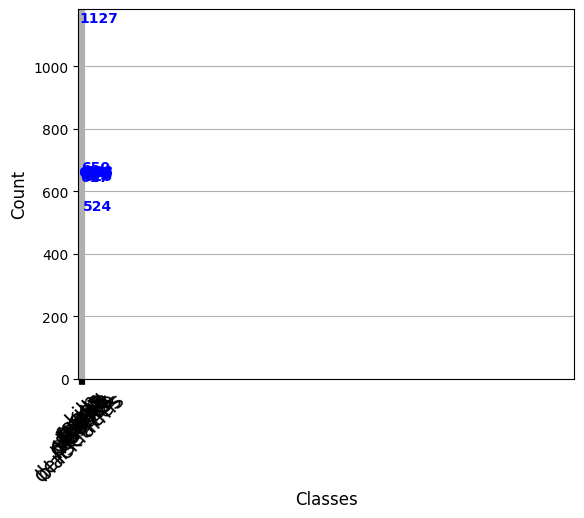

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

folders = os.listdir(dataset_path)
names, counts = [], []
for i, folder in enumerate(folders):
    #skip if the folder is ".DS_Store"
    if folder == '.DS_Store':
        continue

    dir_path = os.path.join(dataset_path, folder)
    images = os.listdir(dir_path)
    names.append(folder)
    counts.append(len(images))
    print(i, folder, len(images))

df = pd.DataFrame(data={'Name': names, 'Count': counts})
ax = df.plot(kind='bar', xticks=counts, grid=True, legend=False) #old had figsize=(16,6)
ax.set_xlabel('Classes', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(np.arange(len(names)), names, rotation=45, fontsize=15)
for i, v in enumerate(counts):
    ax.text(i-.18, v+15, str(v), color='blue', fontweight='bold')
plt.show()

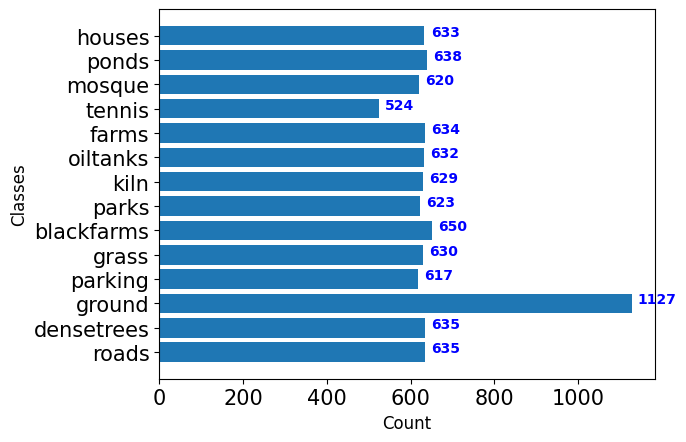

In [8]:
#can we make this plot better?
#I want to rotate the plot so that the classes are on the y-axis and the counts are on the x-axis
#also put the number next to each bar on the right side

df = pd.DataFrame(data={'Name': names, 'Count': counts})
plt.barh(df['Name'], df['Count'])
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
for i, v in enumerate(counts):
    plt.text(v+15, i, str(v), color='blue', fontweight='bold')
plt.ylabel('Classes', fontsize=12)
plt.xlabel('Count', fontsize=12)
plt.show()

In [9]:
batch_size = 10
train_gen = batch_generator(X_train, y_train, batch_size)
val_gen = batch_generator(X_val, y_val, batch_size)
#test_gen = batch_generator(X_test, y_test, batch_size)

In [10]:
#model loading and training
from keras.applications.vgg16 import VGG16
#from keras.applications.vgg19 import VGG19
#from keras.applications.resnet import ResNet50
#from keras.applications.resnet import ResNet101
#from keras.applications.resnet import ResNet152
#from keras.applications.resnet_v2 import ResNet50V2
#from keras.applications.resnet_v2 import ResNet101V2
#from keras.applications.resnet_v2 import ResNet152V2
#from keras.applications.inception_resnet_v2 import InceptionResNetV2
#from keras.applications.inception_v3 import InceptionV3
#from keras.applications.densenet import DenseNet121
#from keras.applications.densenet import DenseNet169
#from keras.applications.densenet import DenseNet201
from keras.activations import softmax, relu, sigmoid
from keras.optimizers import SGD

#uncomment to pick different models
input_shape=(256,256,3)
model= VGG16(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= VGG19(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= ResNet50(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#= ResNet101(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= ResNet152(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= ResNet50V2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= ResNet101V2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
# model= ResNet152V2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= InceptionResNetV2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= InceptionV3(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= DenseNet121(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= DenseNet169(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model= DenseNet201(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model =InceptionResNetV2(include_top=True, weights=None, input_tensor=None, input_shape=input_shape, pooling=None, classes=num_classes)
#model = resNet(input_shape, num_classes, model_type='resnet_152')
#model.load_weights('WEIGHTS/'+model_name+'.h5')

### model_vgg16.layers[-1].activation = relu

### idx_of_layer_to_change = -1
#model.layers[idx_of_layer_to_change].activation = activations.softmax
#model = utils.apply_modifications(model)

#model_vgg16.layers[-1].activation = relu
# # FINE TUNING HERE
# top_model = Sequential()
# top_model.add(Dense(input_shape=model.layers[-2].output_shape, units=num_classes, rnel
# kernel_initializer="he_normal", activation="softmax"))

# model.layers.pop()
# model.outputs = [model.layers[-1].output]
# model.layers[-1].outbound_nodes = []

# model = Model(inputs=model.inputs, outputs=top_model(model.outputs[0]))
# # for layer in model.layers[:-1]:
# #     layer.trainable = False
#model.load_weights('WEIGHTS/'+model_name+'.h5')

model.summary()
sgd = SGD(decay=1e-6, momentum=0.9, nesterov=True) #lr=0.01
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])
# plot_model(model, to_file='model.png')

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 256, 256, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 256, 256, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 128, 128, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 128, 128, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 64, 64, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 64, 64, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 64, 64, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 32, 32, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 32, 32, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 16, 16, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     134,221,824 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 165,775,182 (632.38 MB)

 Trainable params: 165,775,182 (632.38 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [11]:
class_weights = {0: 629/650,
                 1: 629/635,
                 2: 629/634,
                 3: 629/630,
                 4: 629/629,
                 5: 629/633,
                 6: 629/629,
                 7: 629/620,
                 8: 629/632,
                 9: 629/617,
                 10: 629/623,
                 11:629/638,
                 12:629/635,
                 13:629/524
                }

In [12]:
import keras
from keras.callbacks import ModelCheckpoint,TensorBoard,ReduceLROnPlateau,CSVLogger, EarlyStopping
import time

checkpoint = ModelCheckpoint('gdrive/MyDrive/WEIGHTS/'+model_name+'.h5.keras', monitor='val_loss', verbose=2, save_best_only=True, mode='auto') #old 'gdrive/WEIGHTS/'+model_name+'.h5'
tensorboard = TensorBoard(log_dir='gdrive/MyDrive/EVENTS/', write_graph=True, write_images=True) #old: batch_size=batch_size
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2,patience=3, min_lr=0.00001)
earlystop = keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, verbose=2, mode='auto')
cvslogger = keras.callbacks.CSVLogger('gdrive/MyDrive/WEIGHTS/'+model_name+'.csv', separator=',', append=True)

#original epochs: 200
#lowered so that I can run it on my computer
nb_epoch = 200
callbacks = [checkpoint, reduce_lr, earlystop, cvslogger, tensorboard]

#lowering the number of steps so that I can run it on my computer
#i think squaring the batch size will help reduce runtime
train_steps = int(len(y_train)//batch_size) # previously:  int(len(y_train)//(batch_size * batch_size))
val_steps = int(len(y_val)//batch_size) #previously:  int(len(y_val)//(batch_size * batch_size))
start_time = time.time()

history = model.fit(X_train, y_train, epochs=nb_epoch, verbose=1, #old: fit_generator() instead of fit()
                    validation_split = 0.2, shuffle=True,
                    initial_epoch=0, callbacks=callbacks)
#history = model.fit_generator(train_gen, train_steps, epochs=nb_epoch, verbose=1, #old: fit_generator() instead of fit()
 #                   validation_data=val_gen, max_queue_size=2,
 #                   validation_steps=val_steps, shuffle=True,
 #                   workers=1, use_multiprocessing= False,
 #                   initial_epoch=0, callbacks=callbacks, class_weight=class_weights)
print("Seconds: ", time.time() - start_time)
#model.fit(x=X[0:100], y=y[0:100], batch_size=64, epochs=2, verbose=1, callbacks=callbacks,
#          validation_split=0.2, shuffle=True,initial_epoch=0)

Epoch 1/200
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.1215 - loss: 2.6279
Epoch 1: val_loss improved from inf to 6.47633, saving model to gdrive/MyDrive/WEIGHTS/VGG16_Jan2020.h5.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 183s 619ms/step - accuracy: 0.1216 - loss: 2.6273 - val_accuracy: 0.0000e+00 - val_loss: 6.4763 - learning_rate: 0.0100
Epoch 2/200
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.1442 - loss: 2.4024
Epoch 2: val_loss did not improve from 6.47633
231/231 ━━━━━━━━━━━━━━━━━━━━ 80s 348ms/step - accuracy: 0.1442 - loss: 2.4023 - val_accuracy: 0.0000e+00 - val_loss: 8.4152 - learning_rate: 0.0100
Epoch 3/200
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.1444 - loss: 2.3857
Epoch 3: val_loss improved from 6.47633 to 5.95059, saving model to gdrive/MyDrive/WEIGHTS/VGG16_Jan2020.h5.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 90s 390ms/step - accuracy: 0.1444 - loss: 2.3857 - val_accuracy: 0.0000e+00 - val_loss: 5.9506 - learning_rate: 0.0100
Epoch 4/200
231/2

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 24s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 112,576 (439.75 KB)

 Trainable params: 112,576 (439.75 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step


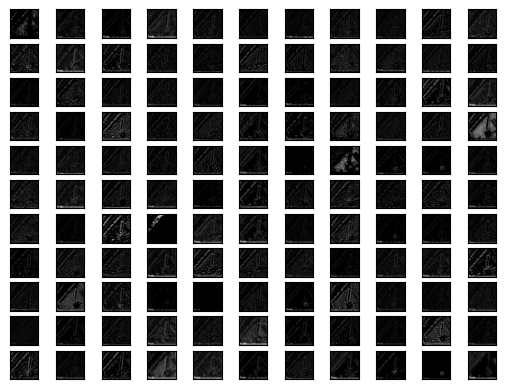

In [13]:
import matplotlib.pyplot as plt
from keras.applications.vgg16 import preprocess_input
from keras.utils import load_img
from keras.utils import img_to_array
from keras.models import Model

model = VGG16()
# redefine model to output right after the first hidden layer
layer_output = model.get_layer('block2_conv1').output
# model = Model(inputs=model.inputs, outputs=model.layers[1].output)
model = Model(inputs=model.inputs, outputs=layer_output)
model.summary()
# load the image with the required shape
img = load_img('kilns/train/parks/74.5291712482_31.5705141576.png', target_size=(224, 224))
# convert the image to an array
img = img_to_array(img)
# expand dimensions so that it represents a single 'sample'
img = np.expand_dims(img, axis=0)
# prepare the image (e.g. scale pixel values for the vgg)
img = preprocess_input(img)
# get feature map for first hidden layer
feature_maps = model.predict(img)
# plot all 64 maps in an 8x8 squares
square = 11
ix = 1
for _ in range(square):
  for _ in range(square):
 # specify subplot and turn of axis
    ax = plt.subplot(square, square, ix)
    ax.set_xticks([])
    ax.set_yticks([])
 # plot filter channel in grayscale
    plt.imshow(feature_maps[0, :, :, ix-1], cmap='gray')
    ix += 1
# show the figure
plt.show()